# SIT307 HD Task - Heart Attack Prediction with Stacking

**Paper:** M. Bhagat, A. Sharma and P. Agarwal, "An efficient stacking-based ensemble technique for
early heart attack prediction", *Multimedia Tools and Applications*, vol. 84, pp. 36351-36375, 2025.

This notebook has three parts:
1. **Part 1 - Reproduction:** I rebuild the paper's six models and the stacking model and compare my results with theirs
2. **Part 1 - Checking the data:** I look into why some of my results are different from the paper
3. **Part 2 - My method:** I fix the problems I found and test my own version of stacking

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, confusion_matrix,
                             brier_score_loss, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

SEED = 42
os.makedirs('results', exist_ok = True)
os.makedirs('figures', exist_ok = True)
pd.set_option('display.precision', 4)

FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

### Helper functions
These are used all through the notebook

In [7]:
def get_metrics(y_true, y_pred, y_prob):
    """Returns all the metrics I report (the paper's metrics plus AUC and Brier score)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_prob),
        'Specificity': tn / (tn + fp),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_prob),
    }
    
def get_six_models(seed=SEED):
    """The six classifiers from the paper. The paper gives no settings, so I use the defaults."""
    return [
        ('LR', LogisticRegression(max_iter = 1000)),
        ('DT', DecisionTreeClassifier(random_state = seed)),
        ('RF', RandomForestClassifier(random_state = seed)),
        ('XGB', XGBClassifier(random_state = seed, eval_metric = 'logloss', n_jobs = 1)),
        ('NB', GaussianNB()),
        ('KNN', KNeighborsClassifier()),
    ]

def paper_preprocessing():
    """Paper: fill missing values with linear regression, then normalise."""
    return Pipeline([
        ('impute', IterativeImputer(estimator=LinearRegression(), random_state=SEED)),
        ('scale', StandardScaler()),
    ])


def paper_stacking(seed=SEED):
    """Paper: 5-fold stacking of all six models. The meta-classifier is not named,
    so I use Logistic Regression (the scikit-learn default)."""
    return StackingClassifier(estimators = get_six_models(seed),
                              final_estimator = LogisticRegression(max_iter = 1000),
                              cv = 5, stack_method = 'predict_proba')

def paper_models(seed=SEED):
    """All seven models from the paper, each with the paper's preprocessing in front."""
    models = {}
    for name, model in get_six_models(seed):
        models[name] = Pipeline([('prep', paper_preprocessing()), ('clf', model)])
    models['Stacking'] = Pipeline([('prep', paper_preprocessing()), ('clf', paper_stacking(seed))])
    return models


def load_uci(site):
    """Loads one of the original UCI hospital files ('cleveland', 'hungarian', 'switzerland', 'va').
    '?' means missing. Cholesterol = 0 is impossible, so I treat it as missing too.
    Disease = 1 when num > 0 (the normal way this dataset is used)."""
    cols = FEATURES + ['num']
    df = pd.read_csv(f'data/uci/processed.{site}.data', names = cols, na_values = '?')
    df.loc[df['chol'] == 0, 'chol'] = np.nan
    df['target'] = (df['num'] > 0).astype(int)
    return df.drop(columns='num')

# PART 1 - Reproducing the paper

How I followed the paper:

| Step | Paper | What I did |
|---|---|---|
| Data | Kaggle heart disease dataset, 1025 rows, 13 features | same file (`data/heart.csv`) |
| Missing values | linear regression imputation | `IterativeImputer` with `LinearRegression` (nothing is actually missing) |
| Encoding | "encoding the categories" | the features are already numbers, so I kept them |
| Scaling | normalisation | `StandardScaler`, fitted on the training set only |
| Split | 80/20 (their test set has 205 rows) | `train_test_split(test_size=0.2)`, seed 42 |
| Models | LR, DT, RF, XGB, NB, KNN | default settings |
| Ensemble | 5-fold stacking | `StackingClassifier(cv=5)` with LR as meta-classifier |

In [4]:
df = pd.read_csv('data/heart.csv')
print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
print('Classes:', df['target'].value_counts().to_dict())
df.head()

Shape: (1025, 14)
Missing values: 0
Classes: {1: 526, 0: 499}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 1.1 One 80/20 split (same as the paper)

In [8]:
X = df[FEATURES]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = SEED)
print('Train size:', len(X_train), '| Test size:', len(X_test))

results = []
probs = {}
preds = {}
for name, model in paper_models().items():
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)
    probs[name] = model.predict_proba(X_test)[:, 1]
    row = get_metrics(y_test, preds[name], probs[name])
    row['Model'] = name
    results.append(row)

part1 = pd.DataFrame(results).set_index('Model')
part1.to_csv('results/part1_single_split.csv')
part1

Train size: 820 | Test size: 205


,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,Brier
Model,,,,,,,,
LR,0.7951,0.7563,0.8738,0.8108,0.8787,0.7157,0.5973,0.1473
DT,0.9854,1.0000,0.9709,0.9852,0.9854,1.0000,0.9712,0.0146
RF,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712,0.0120
XGB,0.9854,1.0000,0.9709,0.9852,0.9894,1.0000,0.9712,0.0150
NB,0.8000,0.7541,0.8932,0.8178,0.8706,0.7059,0.6102,0.1627
KNN,0.8341,0.8000,0.8932,0.8440,0.9486,0.7745,0.6727,0.0919
Stacking,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712,0.0129


## 1.2 Comparing with the paper (Table 11)

In [20]:
paper = pd.DataFrame({
    'Accuracy':  [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    'Precision': [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0000],
    'Recall':    [0.9090, 0.8909, 0.9545, 0.9090, 0.9000, 0.8727, 0.9727],
    'F1':        [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    'AUC':       [0.9204, 0.9702, 0.9734, 0.9830, 0.9185, 0.9304, 0.9880],
}, index=['LR', 'DT', 'RF', 'XGB', 'NB', 'KNN', 'Stacking'])

compare = pd.DataFrame({
    'Paper accuracy': paper['Accuracy'],
    'My accuracy': part1['Accuracy'],
    'Paper F1': paper['F1'],
    'My F1': part1['F1'],
    'Paper AUC': paper['AUC'],
    'My AUC': part1['AUC'],
})
compare['Accuracy difference'] = compare['My accuracy'] - compare['Paper accuracy']
compare.to_csv('results/part1_vs_paper.csv')
compare.round(4)

,Paper accuracy,My accuracy,Paper F1,My F1,Paper AUC,My AUC,Accuracy difference
LR,0.8439,0.7951,0.8620,0.8108,0.9204,0.8787,-0.0488
DT,0.9268,0.9854,0.9289,0.9852,0.9702,0.9854,0.0586
RF,0.9268,0.9854,0.9333,0.9852,0.9734,1.0000,0.0586
XGB,0.9073,0.9854,0.9132,0.9852,0.9830,0.9894,0.0781
NB,0.8439,0.8000,0.8608,0.8178,0.9185,0.8706,-0.0439
KNN,0.8585,0.8341,0.8687,0.8440,0.9304,0.9486,-0.0244
Stacking,0.9853,0.9854,0.9861,0.9852,0.9880,1.0000,0.0001


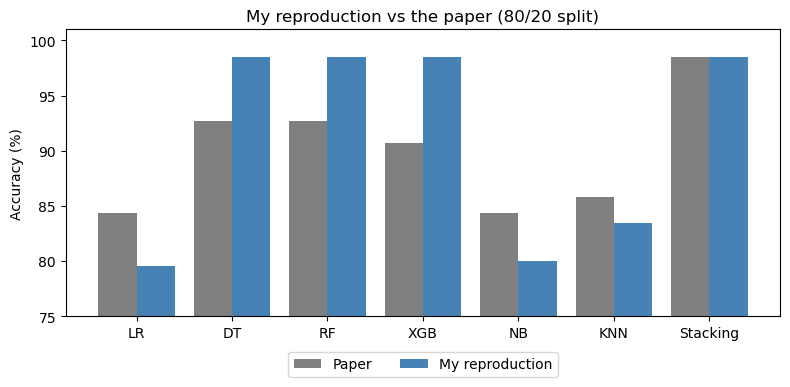

In [12]:
names = list(paper.index)
x = np.arange(len(names))
plt.figure(figsize = (8, 4))
plt.bar(x - 0.2, paper['Accuracy'] * 100, 0.4, label = 'Paper', color='grey')
plt.bar(x + 0.2, part1.loc[names, 'Accuracy'] * 100, 0.4, label = 'My reproduction', color = 'steelblue')
plt.xticks(x, names)
plt.ylim(75, 101)
plt.ylabel('Accuracy (%)')
plt.title('My reproduction vs the paper (80/20 split)')
plt.legend(loc='upper center', bbox_to_anchor = (0.5, -0.1), ncol = 2)
plt.tight_layout()
plt.savefig('figures/part1_accuracy_vs_paper.png', dpi = 200)
plt.show()

## 1.3 Confusion matrices and ROC curves

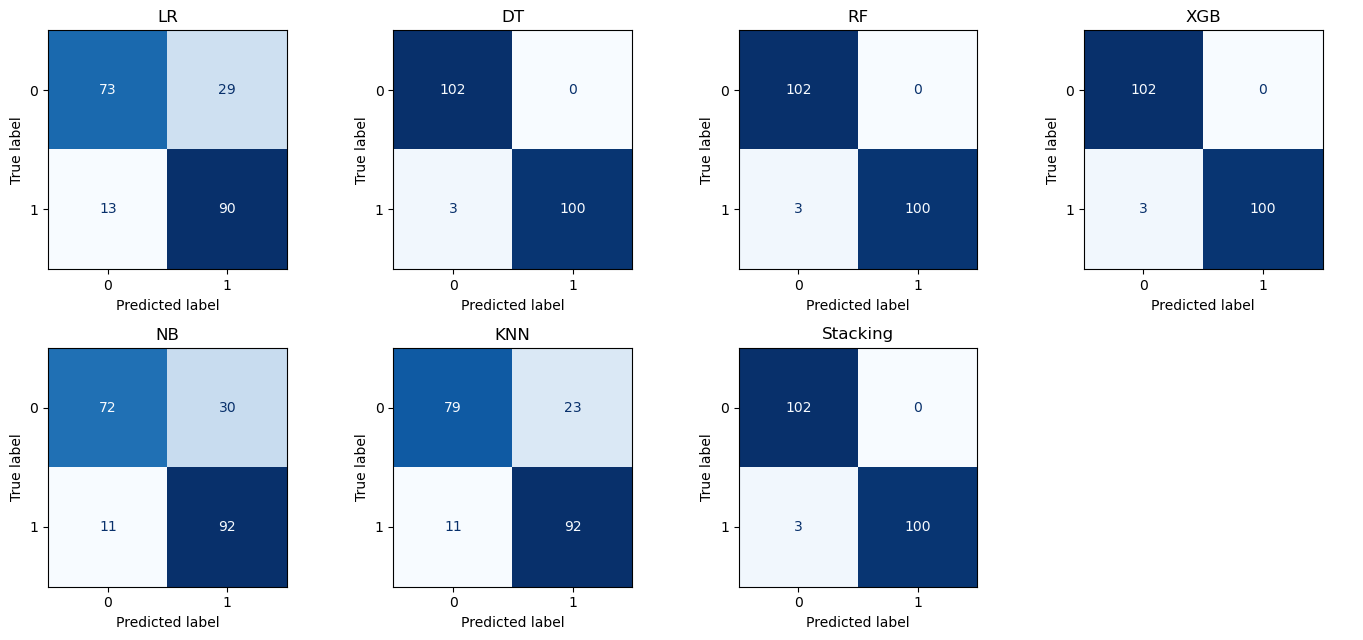

In [13]:
fig, axes = plt.subplots(2, 4, figsize = (14, 6.5))
for ax, name in zip(axes.ravel(), preds):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap = 'Blues')
    ax.set_title(name)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig('figures/part1_confusion_matrices.png', dpi=200)
plt.show()

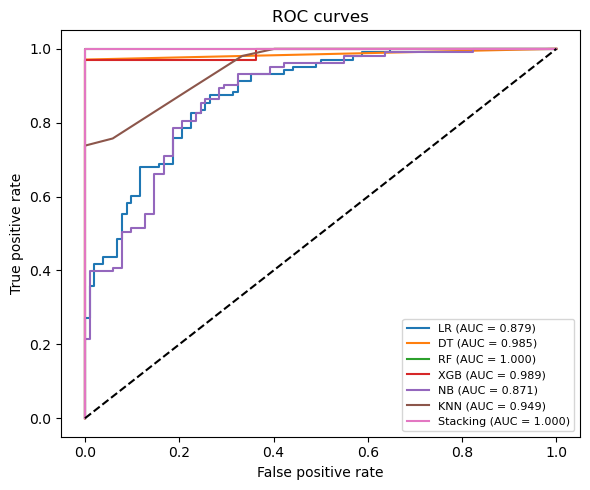

In [15]:
plt.figure(figsize = (6, 5))
for name in probs:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    plt.plot(fpr, tpr, label = f'{name} (AUC = {roc_auc_score(y_test, probs[name]):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves')
plt.legend(fontsize = 8)
plt.tight_layout()
plt.savefig('figures/part1_roc.png', dpi = 200)
plt.show()

**Note on the paper's ROC curves:** in the paper's Fig. 4 every curve has only one corner. That happens
when the ROC is drawn from 0/1 predictions instead of probabilities. Below I compare both ways.

In [16]:
auc_check = pd.DataFrame({
    'AUC from probabilities': {n: roc_auc_score(y_test, probs[n]) for n in probs},
    'AUC from 0/1 predictions': {n: roc_auc_score(y_test, preds[n]) for n in preds},
})
auc_check

,AUC from probabilities,AUC from 0/1 predictions
LR,0.8787,0.7947
DT,0.9854,0.9854
RF,1.0000,0.9854
XGB,0.9894,0.9854
NB,0.8706,0.7995
KNN,0.9486,0.8339
Stacking,1.0000,0.9854


## 1.4 Repeating the split 50 times
One test set of 205 rows can be lucky or unlucky, and the paper doesn't say which random seed it used.
So I repeat the whole thing with 50 different seeds and look at the average

In [17]:
N_SPLITS = 50
repeat_rows = []
for seed in range(N_SPLITS):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size = 0.2, random_state = seed)
    for name, model in paper_models(seed).items():
        model.fit(Xa, ya)
        row = get_metrics(yb, model.predict(Xb), model.predict_proba(Xb)[:, 1])
        row['Model'] = name
        row['seed'] = seed
        repeat_rows.append(row)

repeats = pd.DataFrame(repeat_rows)
repeat_summary = repeats.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].agg(['mean', 'std']).loc[names]
repeat_summary.to_csv('results/part1_50_splits.csv')
repeat_summary

Accuracy         Precision          Recall              F1          \
             mean     std      mean     std    mean     std    mean     std   
Model                                                                         
LR         0.8431  0.0219    0.8171  0.0340  0.8972  0.0295  0.8546  0.0214   
DT         0.9967  0.0082    0.9964  0.0115  0.9972  0.0086  0.9967  0.0080   
RF         0.9982  0.0056    0.9988  0.0059  0.9978  0.0076  0.9983  0.0055   
XGB        0.9974  0.0071    0.9977  0.0096  0.9973  0.0098  0.9974  0.0068   
NB         0.8279  0.0228    0.8114  0.0339  0.8680  0.0321  0.8381  0.0241   
KNN        0.8504  0.0245    0.8533  0.0408  0.8591  0.0315  0.8553  0.0236   
Stacking   0.9974  0.0076    0.9977  0.0098  0.9972  0.0084  0.9974  0.0075   

             AUC          
            mean     std  
Model                     
LR        0.9202  0.0153  
DT        0.9967  0.0081  
RF        0.9999  0.0003  
XGB       0.9996  0.0017  
NB        0.9077  0.0168  
KNN       0.9580  0.0109  
Stacking  0.9998  0.0006

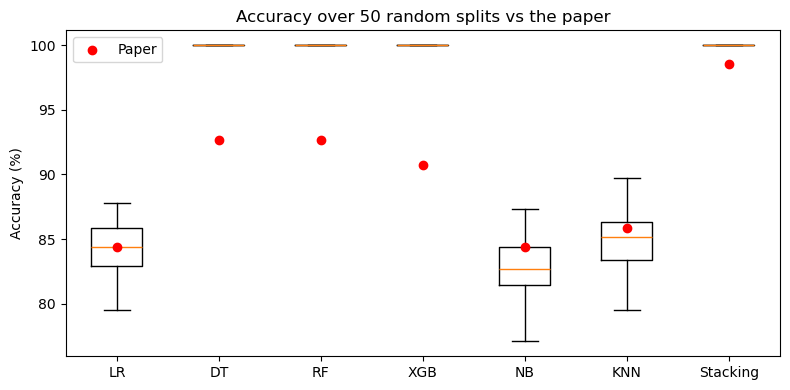

In [19]:
plt.figure(figsize = (8, 4))
plt.boxplot([repeats.loc[repeats.Model == n, 'Accuracy'] * 100 for n in names], labels = names, showfliers = False)
plt.scatter(np.arange(1, len(names) + 1), paper['Accuracy'] * 100, color = 'red', zorder = 3, label = 'Paper')
plt.ylabel('Accuracy (%)')
plt.title(f'Accuracy over {N_SPLITS} random splits vs the paper')
plt.legend()
plt.tight_layout()
plt.savefig('figures/part1_boxplot.png', dpi = 200)
plt.show()

**What I found in Part 1:**

| Model | Paper | My split (seed 42) | My 50-split mean ± std |
|---|---|---|---|
| LR | 84.39% | 79.51% | 84.31% ± 2.19 |
| DT | 92.68% | 98.54% | 99.67% ± 0.82 |
| RF | 92.68% | 98.54% | 99.82% ± 0.56 |
| XGB | 90.73% | 98.54% | 99.74% ± 0.71 |
| NB | 84.39% | 80.00% | 82.79% ± 2.28 |
| KNN | 85.85% | 83.41% | 85.04% ± 2.45 |
| Stacking | 98.53% | 98.54% | 99.74% ± 0.76 |

- **Stacking matches the paper** (98.54% vs 98.53%, both with 3 errors out of 205)
- **LR, NB and KNN** are lower on my one split, but the 50-split average is very close to the paper
  (LR 84.31% vs 84.39%, and LR AUC 0.9202 vs 0.9204). So the difference is just random splitting
- **DT, RF and XGB are much higher than the paper** (about 99.7% vs 91-93%). The paper's values are
  7-9 standard deviations below my average, so this can't be random splitting
- DT, RF, XGB and Stacking all make **the same 3 mistakes**, which suggests they are remembering
  the training data instead of learning general patterns
- The paper's Fig. 4 ROC curves look like they were drawn from 0/1 predictions. From 0/1 predictions my
  LR AUC is 0.795, but from probabilities it's 0.879, and the paper's curves and AUC values don't match

A decision tree getting almost 100% on new patients is suspicious, so I check the data in the next section


# PART 1 (continued) - Checking the data

## 2.1 Duplicate rows

In [21]:
n_duplicates = df.duplicated().sum()
unique_df = df.drop_duplicates().reset_index(drop = True)
print('Total rows:', len(df))
print('Duplicate rows:', n_duplicates)
print('Unique patients:', len(unique_df))

Total rows: 1025
Duplicate rows: 723
Unique patients: 302


## 2.2 How many test patients are also in the training set?

In [22]:
train_rows = set(map(tuple, pd.concat([X_train, y_train], axis = 1).values))
test_rows = pd.concat([X_test, y_test], axis = 1).values
in_train = np.array([tuple(r) in train_rows for r in test_rows])
print(f'Test rows that also appear in training: {in_train.sum()} out of {len(in_train)} ({in_train.mean():.1%})')

Test rows that also appear in training: 199 out of 205 (97.1%)


So almost every "test" patient was already seen during training. The tree models can just remember them,
which explains the ~100% results

## 2.3 Same pipeline, but duplicates removed first
Everything is the same as section 1.4, except I drop the duplicates **before** splitting

In [23]:
Xu = unique_df[FEATURES]
yu = unique_df['target']
dedup_rows = []
for seed in range(N_SPLITS):
    Xa, Xb, ya, yb = train_test_split(Xu, yu, test_size = 0.2, random_state = seed)
    for name, model in paper_models(seed).items():
        model.fit(Xa, ya)
        row = get_metrics(yb, model.predict(Xb), model.predict_proba(Xb)[:, 1])
        row['Model'] = name
        dedup_rows.append(row)
dedup = pd.DataFrame(dedup_rows)

leak_table = pd.DataFrame({
    'Paper': paper['Accuracy'],
    'With duplicates': repeats.groupby('Model')['Accuracy'].mean(),
    'Duplicates removed': dedup.groupby('Model')['Accuracy'].mean(),
}).loc[names]
leak_table['Drop (%)'] = (leak_table['With duplicates'] - leak_table['Duplicates removed']) * 100
leak_table.to_csv('results/part1_duplicate_effect.csv')
leak_table

,Paper,With duplicates,Duplicates removed,Drop (%)
LR,0.8439,0.8431,0.8259,1.7220
DT,0.9268,0.9967,0.7482,24.8486
RF,0.9268,0.9982,0.8148,18.3490
XGB,0.9073,0.9974,0.7892,20.8186
NB,0.8439,0.8279,0.8121,1.5771
KNN,0.8585,0.8504,0.8108,3.9619
Stacking,0.9853,0.9974,0.8252,17.2120


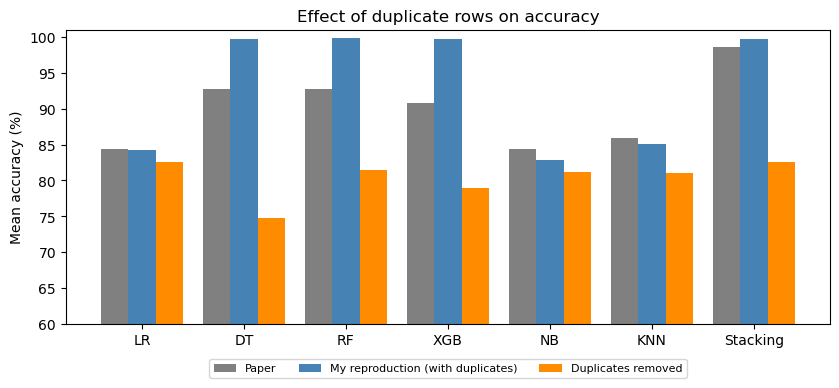

In [24]:
plt.figure(figsize=(8.5, 4))
plt.bar(x - 0.27, leak_table['Paper'] * 100, 0.27, label = 'Paper', color = 'grey')
plt.bar(x, leak_table['With duplicates'] * 100, 0.27, label = 'My reproduction (with duplicates)', color  ='steelblue')
plt.bar(x + 0.27, leak_table['Duplicates removed'] * 100, 0.27, label = 'Duplicates removed', color = 'darkorange')
plt.xticks(x, names)
plt.ylim(60, 101)
plt.ylabel('Mean accuracy (%)')
plt.title('Effect of duplicate rows on accuracy')
plt.legend(fontsize = 8, loc = 'upper center', bbox_to_anchor = (0.5, -0.1), ncol = 3)
plt.tight_layout()
plt.savefig('figures/part1_duplicate_effect.png', dpi = 200)
plt.show()

**What this shows:** once duplicates are removed, the tree models drop a lot (DT -24.8, XGB -20.8, RF -18.3 percentage points) and Stacking drops 17.2 points to 82.52%. LR, NB and KNN barely change (-1.6 to -4.0 points) because they can't memorise rows like trees can

The most important result: **on unique patients, Stacking (82.52%) is no better than plain Logistic Regression (82.59%).** The paper's main claim, that stacking greatly improves accuracy, only holds when test patients are repeated from training

The paper's DT/RF/XGB values (91-93%) are between my leaky (~99.7%) and fair (75-81%) results, so they can't be fully explained by duplicates either. The paper doesn't give its model settings, so the exact reason is unknown

## 2.4 Where does the data come from?
The paper says the dataset combines four hospitals (Cleveland, Hungary, Switzerland, Long Beach).
I matched each unique row to the original UCI Cleveland file using columns that don't change between
versions (age, sex, blood pressure, cholesterol, max heart rate, ST depression)

In [25]:
cleveland = load_uci('cleveland')
match_cols = ['age', 'sex', 'trestbps', 'chol', 'thalach', 'oldpeak']
matched = unique_df.merge(cleveland, on = match_cols, suffixes = ('_kaggle', '_uci'))
print('Unique Kaggle rows:', len(unique_df))
print('Matched to Cleveland:', len(matched))

Unique Kaggle rows: 302
Matched to Cleveland: 302


All of them match Cleveland, so the data only comes from one hospital, not four

Now I compare the target and some category codes between the two versions

In [45]:
print('Target (rows = Kaggle, columns = real UCI disease label):')
display(pd.crosstab(matched['target_kaggle'], matched['target_uci']))
print('Chest pain type (UCI: 1 = typical angina ... 4 = asymptomatic):')
display(pd.crosstab(matched['cp_kaggle'], matched['cp_uci']))
print('thal (UCI: 3 = normal, 6 = fixed defect, 7 = reversible defect):')
display(pd.crosstab(matched['thal_kaggle'], matched['thal_uci'].fillna('missing')))
print('Rows with ca = 4:', (df['ca'] == 4).sum(), '| rows with thal = 0:', (df['thal'] == 0).sum())

Target (rows = Kaggle, columns = real UCI disease label):


target_uci,0,1
target_kaggle,,
0,0,138
1,164,0


Chest pain type (UCI: 1 = typical angina ... 4 = asymptomatic):


cp_uci,1.0,2.0,3.0,4.0
cp_kaggle,,,,
0,0,0,0,143
1,0,50,0,0
2,0,0,86,0
3,23,0,0,0


thal (UCI: 3 = normal, 6 = fixed defect, 7 = reversible defect):


thal_uci,3.0,6.0,7.0,missing
thal_kaggle,,,,
0,0,0,0,2
1,0,18,0,0
2,165,0,0,0
3,0,0,117,0


Rows with ca = 4: 18 | rows with thal = 0: 7


What this shows:
- **All 302 unique patients come from Cleveland only**, not four hospitals as the paper says
- **The target is flipped.** Kaggle 0 = disease (138 patients) and Kaggle 1 = no disease (164). The paper says 1 = disease, so its "recall" and "precision" are really about finding healthy people
- **Chest pain codes don't match the paper.** Kaggle 0 = asymptomatic (not typical angina) and 3 = typical angina; codes 1 and 2 are in the same order as UCI
- **thal codes are different:** Kaggle 1 = fixed defect, 2 = normal, 3 = reversible, but the paper says 1 = normal, 2 = fixed. Kaggle `thal = 0` (7 rows) and `ca = 4` (18 rows) are really missing values, even though the paper says there are only 0-3 vessels and 1-3 for thal

## 2.5 Checking the paper's Table 11
Some columns in Table 11 look exactly the same as other columns:

In [29]:
table11 = pd.DataFrame({
    'Accuracy':    [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    'Sensitivity': [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    'F1':          [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    'Specificity': [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    'Precision':   [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0],
    'MCC':         [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0],
}, index = names)
print('Sensitivity is the same as Accuracy:', (table11['Sensitivity'] == table11['Accuracy']).all())
print('Specificity is the same as F1:      ', (table11['Specificity'] == table11['F1']).all())
print('MCC is the same as Precision:       ', (table11['MCC'] == table11['Precision']).all())

# Recalculate from the paper's own confusion matrix for stacking (Fig. 5)
tn, fp, fn, tp = 95, 0, 3, 107
mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
print(f'\nFrom Fig. 5: sensitivity = {tp/(tp+fn):.4f}, specificity = {tn/(tn+fp):.4f}, MCC = {mcc:.4f}')
print('Paper says:   sensitivity = 0.9853, specificity = 0.9861, MCC = 1.0000')

Sensitivity is the same as Accuracy: True
Specificity is the same as F1:       True
MCC is the same as Precision:        True

From Fig. 5: sensitivity = 0.9727, specificity = 1.0000, MCC = 0.9711
Paper says:   sensitivity = 0.9853, specificity = 0.9861, MCC = 1.0000


 **What this shows:** three columns in Table 11 are exact copies of other columns, so the paper's reported sensitivity, specificity and MCC are wrong. Using the paper's own confusion matrix (Fig. 5), the stacking model's real values are sensitivity 0.9727, specificity 1.0000 and MCC 0.9711, not 0.9853, 0.9861 and 1.0000

**Summary of the data checks:** the paper's 98.53% comes from test patients that were already in the training set. The dataset description (source, labels, codes) is also wrong, and some reported metrics are copied from other columns. These are the problems I fix in Part 2

# PART 2 - My proposed method: LSC-Stack

**Problems I found in the paper:**
1. Duplicate patients in both train and test sets make the results look much better than they are
2. The labels and category codes are described wrongly, and category codes (like chest pain type) are
   treated as normal numbers
3. All six models are stacked without checking if they actually help
4. The model uses a 0.5 cut-off, which isn't a good choice when missing a heart attack is much worse
   than a false alarm
5. Only one random split, and no confidence intervals or significance tests

**My method (LSC-Stack = Leakage-free, Selective, Clinical-threshold Stacking):**
1. Use the original UCI Cleveland data (303 patients, correct labels: 1 = disease)
2. **Better preprocessing** inside each training fold: one-hot encode the category features, fill
   missing values, scale the numbers
3. **Selective stacking:** only keep base models that actually improve the stack
4. **Clinical threshold:** choose the cut-off so that at least 90% of disease cases are caught
5. **Proper testing:** 10 x 5-fold cross-validation, 95% confidence intervals, a significance test,
   and testing on three other hospitals the model has never seen

In [30]:
X = cleveland[FEATURES]
y = cleveland['target']
print('Patients:', len(X), '| disease rate:', round(y.mean(), 3))
print('Missing values:', X.isna().sum()[X.isna().sum() > 0].to_dict())

Patients: 303 | disease rate: 0.459
Missing values: {'ca': 4, 'thal': 2}


## 3.1 My preprocessing
Numbers get scaled, yes/no features stay as they are, and category features get one-hot encoded

In [32]:
NUMERIC = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BINARY = ['sex', 'fbs', 'exang']
CATEGORY = ['cp', 'restecg', 'slope', 'thal']

def my_preprocessing():
    numeric = Pipeline([('impute', SimpleImputer(strategy = 'median')), ('scale', StandardScaler())])
    binary = SimpleImputer(strategy = 'most_frequent')
    category = Pipeline([('impute', SimpleImputer(strategy = 'most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])
    return ColumnTransformer([('num', numeric, NUMERIC), ('bin', binary, BINARY), ('cat', category, CATEGORY)])

## 3.2 Selective stacking with a clinical threshold
`train_lsc` does everything on the training data only:
1. Gets out-of-fold probabilities from each of the six models (5-fold CV)
2. Starts with the best single model, then adds models one at a time **only if** the stack's AUC goes up by at least 0.002
3. Picks the highest threshold that still catches at least 90% of disease cases
4. Trains the chosen models on all the training data, and trains the meta-model (LR) on their out-of-fold probabilities

In [ ]:
def stack_auc(prob_columns, y, folds):
    """AUC of a logistic regression meta-model trained on the given out-of-fold probabilities."""
    Z = np.column_stack(prob_columns)
    meta_probs = cross_val_predict(LogisticRegression(max_iter = 1000), Z, y, cv = folds, method = 'predict_proba')[:, 1]
    return roc_auc_score(y, meta_probs), meta_probs


def train_lsc(X_train, y_train, target_recall = 0.90, seed = SEED):
    y_train = np.asarray(y_train)
    prep = my_preprocessing().fit(X_train)
    Xp = prep.transform(X_train)
    folds = StratifiedKFold(5, shuffle = True, random_state = seed)
    models = dict(get_six_models(seed))

    # step 1: out-of-fold probabilities for every model
    oof = {}
    for name, model in models.items():
        oof[name] = cross_val_predict(clone(model), Xp, y_train, cv = folds, method = 'predict_proba')[:, 1]

    # step 2: forward selection
    first = max(oof, key = lambda n: roc_auc_score(y_train, oof[n]))
    chosen = [first]
    best_auc, meta_probs = stack_auc([oof[first]], y_train, folds)
    while True:
        best_new, best_new_auc, best_new_probs = None, best_auc, None
        for name in oof:
            if name in chosen:
                continue
            auc, probs_ = stack_auc([oof[n] for n in chosen + [name]], y_train, folds)
            if auc > best_new_auc:
                best_new, best_new_auc, best_new_probs = name, auc, probs_
        if best_new is None or best_new_auc - best_auc < 0.002:
            break
        chosen.append(best_new)
        best_auc, meta_probs = best_new_auc, best_new_probs

    # step 3: threshold (None = normal 0.5)
    threshold = 0.5
    if target_recall is not None:
        for t in sorted(np.unique(meta_probs), reverse = True):
            if (meta_probs[y_train == 1] >= t).mean() >= target_recall:
                threshold = t
                break

    # step 4: final training
    fitted = [clone(models[n]).fit(Xp, y_train) for n in chosen]
    meta = LogisticRegression(max_iter = 1000).fit(np.column_stack([oof[n] for n in chosen]), y_train)
    return {'prep': prep, 'models': fitted, 'meta': meta, 'chosen': chosen, 'threshold': threshold}


def lsc_predict_proba(lsc, X_new):
    Xp = lsc['prep'].transform(X_new)
    Z = np.column_stack([m.predict_proba(Xp)[:, 1] for m in lsc['models']])
    return lsc['meta'].predict_proba(Z)[:, 1]


def lsc_predict(lsc, X_new):
    return (lsc_predict_proba(lsc, X_new) >= lsc['threshold']).astype(int)

## 3.3 What I compare
All methods use exactly the same folds, so the comparison is fair

| Name | Preprocessing | Stacking | Threshold |
|---|---|---|---|
| LR, DT, RF, XGB, NB, KNN | paper | - | 0.5 |
| **Paper-Stack** (baseline) | paper | all six | 0.5 |
| Ablation A | mine | all six | 0.5 |
| Ablation B | mine | selective | 0.5 |
| **LSC-Stack** (mine) | mine | selective | 90% recall |

The two ablations show how much each part of my method changes the result

In [35]:
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 10, random_state = SEED)
cv_rows = []
chosen_log = []
oof_first_repeat = {'Paper-Stack': [], 'LSC-Stack': [], 'LR': []}

for fold, (tr, te) in enumerate(cv.split(X, y)):
    X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
    seed = SEED + fold
    fold_results = {}

    # six single models + the paper's stacking
    for name, model in paper_models(seed).items():
        model.fit(X_tr, y_tr)
        label = 'Paper-Stack' if name == 'Stacking' else name
        fold_results[label] = (model.predict(X_te), model.predict_proba(X_te)[:, 1])

    # Ablation A: my preprocessing + stacking all six
    abl_a = Pipeline([('prep', my_preprocessing()), ('clf', paper_stacking(seed))]).fit(X_tr, y_tr)
    fold_results['Ablation A'] = (abl_a.predict(X_te), abl_a.predict_proba(X_te)[:, 1])

    # Ablation B: my preprocessing + selective stacking, threshold 0.5
    abl_b = train_lsc(X_tr, y_tr, target_recall = None, seed = seed)
    fold_results['Ablation B'] = (lsc_predict(abl_b, X_te), lsc_predict_proba(abl_b, X_te))

    # LSC-Stack: the full method
    lsc = train_lsc(X_tr, y_tr, target_recall = 0.90, seed = seed)
    fold_results['LSC-Stack'] = (lsc_predict(lsc, X_te), lsc_predict_proba(lsc, X_te))
    chosen_log.append({'fold': fold, 'chosen': '+'.join(lsc['chosen']), 'threshold': lsc['threshold']})

    for name, (pred, prob) in fold_results.items():
        row = get_metrics(y_te, pred, prob)
        row['Method'] = name
        row['fold'] = fold
        cv_rows.append(row)
        if fold < 5 and name in oof_first_repeat:
            oof_first_repeat[name].append(pd.DataFrame({'y': y_te.values, 'p': prob}))

    print(f'fold {fold + 1}/50 done')

cv_results = pd.DataFrame(cv_rows)
cv_results.to_csv('results/part2_cv_all_folds.csv', index = False)

fold 1/50 done
fold 2/50 done
fold 3/50 done
fold 4/50 done
fold 5/50 done
fold 6/50 done
fold 7/50 done
fold 8/50 done
fold 9/50 done
fold 10/50 done
fold 11/50 done
fold 12/50 done
fold 13/50 done
fold 14/50 done
fold 15/50 done
fold 16/50 done
fold 17/50 done
fold 18/50 done
fold 19/50 done
fold 20/50 done
fold 21/50 done
fold 22/50 done
fold 23/50 done
fold 24/50 done
fold 25/50 done
fold 26/50 done
fold 27/50 done
fold 28/50 done
fold 29/50 done
fold 30/50 done
fold 31/50 done
fold 32/50 done
fold 33/50 done
fold 34/50 done
fold 35/50 done
fold 36/50 done
fold 37/50 done
fold 38/50 done
fold 39/50 done
fold 40/50 done
fold 41/50 done
fold 42/50 done
fold 43/50 done
fold 44/50 done
fold 45/50 done
fold 46/50 done
fold 47/50 done
fold 48/50 done
fold 49/50 done
fold 50/50 done


## 3.4 Results (mean ± 95% confidence interval over 50 folds)

In [36]:
def mean_and_ci(values):
    values = np.asarray(values)
    half_width = stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return f'{values.mean():.3f} ± {half_width:.3f}'

order = ['LR', 'DT', 'RF', 'XGB', 'NB', 'KNN', 'Paper-Stack', 'Ablation A', 'Ablation B', 'LSC-Stack']
metric_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Specificity', 'MCC', 'Brier']
part2 = pd.DataFrame({m: cv_results.groupby('Method')[m].apply(mean_and_ci) for m in metric_list}).loc[order]
part2.to_csv('results/part2_cv_summary.csv')
part2

,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,Brier
Method,,,,,,,,
LR,0.836 ± 0.013,0.848 ± 0.019,0.790 ± 0.020,0.815 ± 0.014,0.904 ± 0.010,0.876 ± 0.017,0.673 ± 0.026,0.123 ± 0.007
DT,0.746 ± 0.013,0.724 ± 0.019,0.733 ± 0.020,0.725 ± 0.014,0.745 ± 0.013,0.757 ± 0.022,0.492 ± 0.027,0.254 ± 0.013
RF,0.828 ± 0.014,0.843 ± 0.019,0.775 ± 0.022,0.805 ± 0.016,0.903 ± 0.011,0.873 ± 0.019,0.657 ± 0.028,0.127 ± 0.006
XGB,0.797 ± 0.014,0.798 ± 0.020,0.755 ± 0.021,0.773 ± 0.015,0.879 ± 0.010,0.832 ± 0.021,0.594 ± 0.027,0.160 ± 0.010
NB,0.840 ± 0.013,0.850 ± 0.019,0.798 ± 0.018,0.821 ± 0.014,0.897 ± 0.011,0.876 ± 0.018,0.681 ± 0.026,0.136 ± 0.010
KNN,0.830 ± 0.011,0.834 ± 0.014,0.788 ± 0.018,0.809 ± 0.013,0.890 ± 0.011,0.865 ± 0.013,0.658 ± 0.023,0.129 ± 0.007
Paper-Stack,0.832 ± 0.013,0.839 ± 0.019,0.790 ± 0.020,0.811 ± 0.015,0.908 ± 0.010,0.867 ± 0.018,0.664 ± 0.026,0.122 ± 0.007
Ablation A,0.833 ± 0.011,0.850 ± 0.017,0.779 ± 0.019,0.810 ± 0.013,0.906 ± 0.010,0.879 ± 0.017,0.667 ± 0.022,0.122 ± 0.007
Ablation B,0.837 ± 0.012,0.855 ± 0.018,0.781 ± 0.016,0.814 ± 0.013,0.908 ± 0.010,0.884 ± 0.018,0.674 ± 0.023,0.122 ± 0.007


### Which models did selective stacking keep?

In [37]:
chosen_df = pd.DataFrame(chosen_log)
chosen_df.to_csv('results/part2_chosen_models.csv', index = False)
all_chosen = [m for combo in chosen_df['chosen'] for m in combo.split('+')]
print('How often each model was kept (out of 50 folds):')
print(pd.Series(all_chosen).value_counts().to_string())
print('\nAverage number of models kept:', round(chosen_df['chosen'].str.split('+').apply(len).mean(), 2), '(paper uses 6)')
print('Average threshold:', round(chosen_df['threshold'].mean(), 3))

How often each model was kept (out of 50 folds):
LR     47
RF     28
KNN     6
XGB     2
NB      1

Average number of models kept: 1.68 (paper uses 6)
Average threshold: 0.268


**What this shows:** tested fairly, the paper's stacking gets 83.2% accuracy and AUC 0.908, very close to plain LR (83.6%, AUC 0.904). Ablation A (my preprocessing) and Ablation B (plus selective stacking) give almost the same results

Selective stacking kept only **1.68 models on average** instead of 6 (mostly LR and RF), with the same AUC. So the other four models weren't adding anything

LSC-Stack has the same AUC (0.908) but a much higher recall (0.894 vs 0.790), because the threshold (average 0.268) is set to catch 90% of disease cases. The cost is lower specificity (0.708) and accuracy (79.3%), which is the trade-off I chose on purpose

## 3.5 Significance tests
A normal t-test is too optimistic with cross-validation because the training sets overlap.
So I use the **corrected resampled t-test** (Nadeau and Bengio, 2003), which makes the variance bigger to account for this

In [38]:
def corrected_ttest(a, b, n_train, n_test):
    d = np.asarray(a) - np.asarray(b)
    k = len(d)
    t = d.mean() / np.sqrt((1 / k + n_test / n_train) * d.var(ddof = 1))
    p = 2 * stats.t.sf(abs(t), k - 1)
    return t, p

n_test = len(X) // 5
n_train = len(X) - n_test
test_rows = []
for a, b in [('LSC-Stack', 'Paper-Stack'), ('Ablation A', 'Paper-Stack'),
             ('Ablation B', 'Ablation A'), ('Paper-Stack', 'LR')]:
    for m in ['AUC', 'Accuracy', 'F1', 'Recall', 'Specificity']:
        va = cv_results[cv_results.Method == a].sort_values('fold')[m].values
        vb = cv_results[cv_results.Method == b].sort_values('fold')[m].values
        t, p = corrected_ttest(va, vb, n_train, n_test)
        test_rows.append({'Comparison': f'{a} vs {b}', 'Metric': m,
                          'Difference': va.mean() - vb.mean(), 'p-value': p, 'Significant': p < 0.05})
sig_tests = pd.DataFrame(test_rows)
sig_tests.to_csv('results/part2_significance_tests.csv', index = False)
sig_tests

,Comparison,Metric,Difference,p-value,Significant
0,LSC-Stack vs Paper-Stack,AUC,-0.0006,0.9385,False
1,LSC-Stack vs Paper-Stack,Accuracy,-0.0383,0.0807,False
2,LSC-Stack vs Paper-Stack,F1,-0.0122,0.5721,False
3,LSC-Stack vs Paper-Stack,Recall,0.1045,0.0012,True
4,LSC-Stack vs Paper-Stack,Specificity,-0.1592,0.0002,True
5,Ablation A vs Paper-Stack,AUC,-0.0019,0.7981,False
6,Ablation A vs Paper-Stack,Accuracy,0.0013,0.9249,False
7,Ablation A vs Paper-Stack,F1,-0.0010,0.9435,False
8,Ablation A vs Paper-Stack,Recall,-0.0108,0.5704,False
9,Ablation A vs Paper-Stack,Specificity,0.0115,0.6492,False


**What this shows:**
- **Paper-Stack vs LR:** no significant difference in any metric (AUC p = 0.65), so stacking all six models doesn't beat logistic regression on unique patients
- **Ablations A and B:** no significant changes, so my preprocessing and selection keep the same performance while using fewer models
- **LSC-Stack vs Paper-Stack:** recall is significantly higher (+10.5 points, p = 0.001) and specificity is significantly lower (-15.9 points, p = 0.0002). AUC is unchanged (p = 0.94)

## 3.6 Figures

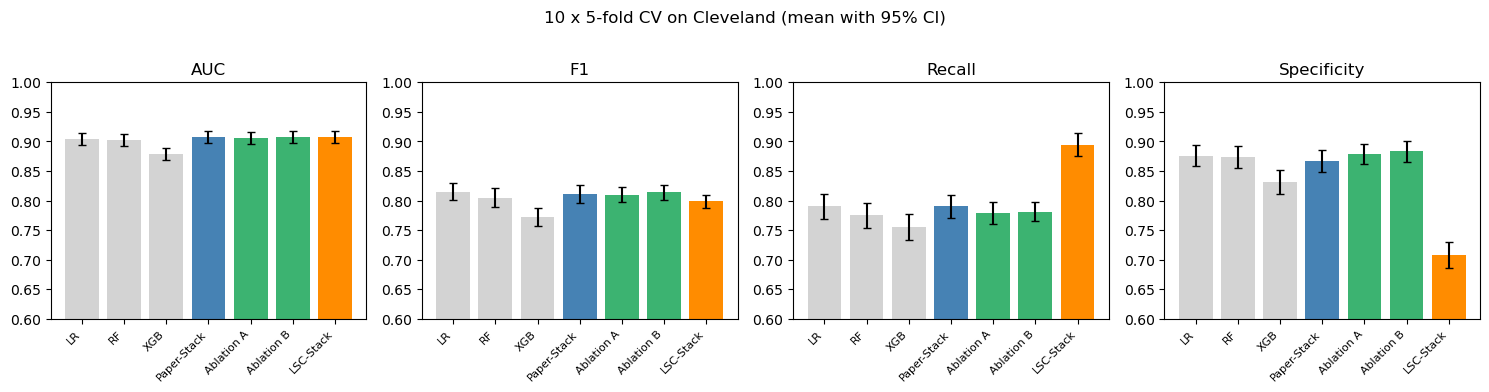

In [39]:
show = ['LR', 'RF', 'XGB', 'Paper-Stack', 'Ablation A', 'Ablation B', 'LSC-Stack']
colours = ['lightgrey', 'lightgrey', 'lightgrey', 'steelblue', 'mediumseagreen', 'mediumseagreen', 'darkorange']
fig, axes = plt.subplots(1, 4, figsize = (15, 3.8))
for ax, m in zip(axes, ['AUC', 'F1', 'Recall', 'Specificity']):
    means = [cv_results[cv_results.Method == s][m].mean() for s in show]
    errors = [stats.t.ppf(0.975, 49) * cv_results[cv_results.Method == s][m].std() / np.sqrt(50) for s in show]
    ax.bar(range(len(show)), means, yerr = errors, color = colours, capsize = 3)
    ax.set_xticks(range(len(show)))
    ax.set_xticklabels(show, rotation = 45, ha = 'right', fontsize = 8)
    ax.set_ylim(0.6, 1.0)
    ax.set_title(m)
plt.suptitle('10 x 5-fold CV on Cleveland (mean with 95% CI)', y = 1.02)
plt.tight_layout()
plt.savefig('figures/part2_results.png', dpi = 200, bbox_inches = 'tight')
plt.show()

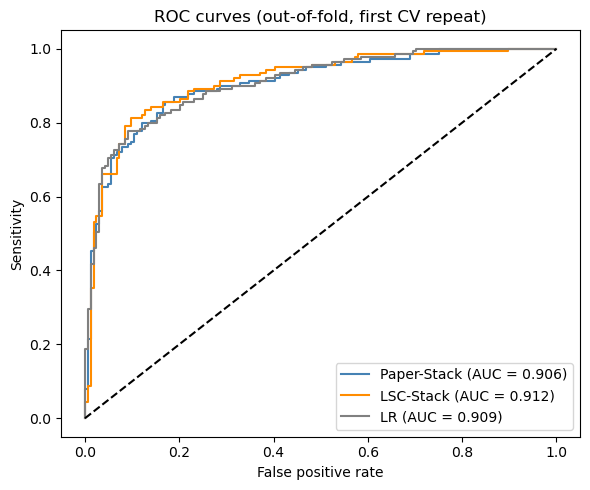

In [40]:
plt.figure(figsize=(6, 5))
for name, colour in [('Paper-Stack', 'steelblue'), ('LSC-Stack', 'darkorange'), ('LR', 'grey')]:
    d = pd.concat(oof_first_repeat[name])
    fpr, tpr, _ = roc_curve(d['y'], d['p'])
    plt.plot(fpr, tpr, color = colour, label = f'{name} (AUC = {roc_auc_score(d.y, d.p):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('Sensitivity')
plt.title('ROC curves (out-of-fold, first CV repeat)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/part2_roc.png', dpi = 200)
plt.show()

## 3.7 Testing on three other hospitals
I train on all 303 Cleveland patients, then test on Hungary, Switzerland and Long Beach VA without
changing anything. These hospitals have lots of missing values, so this is a tough test

In [42]:
other_sites = {site: load_uci(site) for site in ['hungarian', 'switzerland', 'va']}
for site, data in other_sites.items():
    missing = (data[FEATURES].isna().mean() * 100).round()
    print(f'{site}: {len(data)} patients, disease rate {data.target.mean():.2f}, '
          f'columns >20% missing: {missing[missing > 20].to_dict()}')

# train the final models on all of Cleveland
final_models = paper_models()
for name in ['LR', 'RF', 'Stacking']:
    final_models[name].fit(X, y)
final_lsc = train_lsc(X, y, target_recall = 0.90)

external_rows = []
for site, data in other_sites.items():
    Xs, ys = data[FEATURES], data['target']
    for name in ['LR', 'RF', 'Stacking']:
        row = get_metrics(ys, final_models[name].predict(Xs), final_models[name].predict_proba(Xs)[:, 1])
        row['Method'] = 'Paper-Stack' if name == 'Stacking' else name
        row['Site'] = site
        external_rows.append(row)
    row = get_metrics(ys, lsc_predict(final_lsc, Xs), lsc_predict_proba(final_lsc, Xs))
    row['Method'] = 'LSC-Stack'
    row['Site'] = site
    external_rows.append(row)

external = pd.DataFrame(external_rows)[['Site', 'Method', 'AUC', 'Accuracy', 'Recall', 'Specificity', 'F1', 'MCC']]
external.to_csv('results/part2_external.csv', index = False)
external

hungarian: 294 patients, disease rate 0.36, columns >20% missing: {'slope': 65.0, 'ca': 99.0, 'thal': 90.0}
switzerland: 123 patients, disease rate 0.93, columns >20% missing: {'chol': 100.0, 'fbs': 61.0, 'ca': 96.0, 'thal': 42.0}
va: 200 patients, disease rate 0.74, columns >20% missing: {'trestbps': 28.0, 'chol': 28.0, 'thalach': 26.0, 'exang': 26.0, 'oldpeak': 28.0, 'slope': 51.0, 'ca': 99.0, 'thal': 83.0}


,Site,Method,AUC,Accuracy,Recall,Specificity,F1,MCC
0,hungarian,LR,0.8909,0.8435,0.8113,0.8617,0.7890,0.6655
1,hungarian,RF,0.8972,0.8231,0.7358,0.8723,0.7500,0.6135
2,hungarian,Paper-Stack,0.8969,0.8367,0.7547,0.8830,0.7692,0.6433
3,hungarian,LSC-Stack,0.8863,0.8129,0.7642,0.8404,0.7465,0.5988
4,switzerland,LR,0.6902,0.7724,0.7913,0.5000,0.8667,0.1713
5,switzerland,RF,0.7011,0.7724,0.7826,0.6250,0.8654,0.2341
6,switzerland,Paper-Stack,0.7022,0.7642,0.7826,0.5000,0.8612,0.1642
7,switzerland,LSC-Stack,0.7511,0.7805,0.8087,0.3750,0.8732,0.1126
8,va,LR,0.7464,0.7800,0.9128,0.3922,0.8608,0.3580
9,va,RF,0.7557,0.7900,0.9195,0.4118,0.8671,0.3889


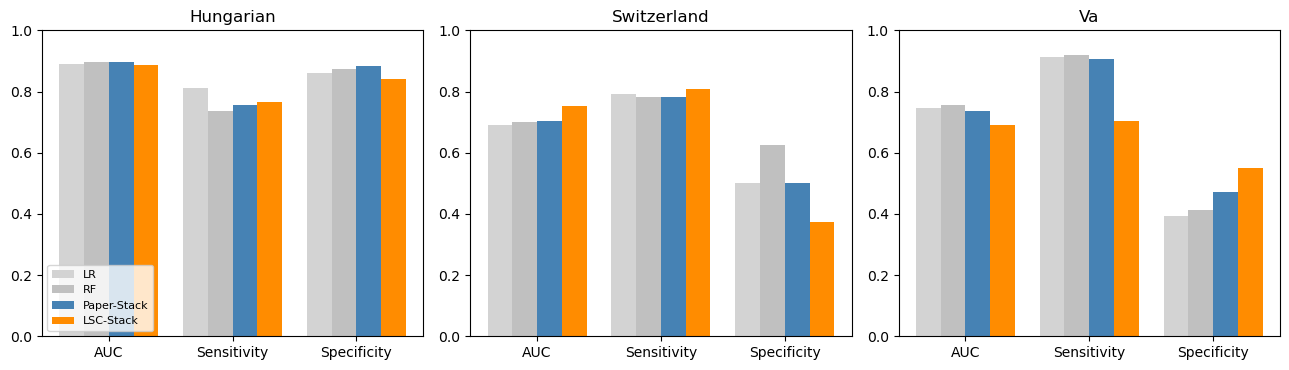

In [43]:
fig, axes = plt.subplots(1, 3, figsize = (13, 3.8))
methods = ['LR', 'RF', 'Paper-Stack', 'LSC-Stack']
colours = ['lightgrey', 'silver', 'steelblue', 'darkorange']
for ax, site in zip(axes, other_sites):
    d = external[external.Site == site].set_index('Method').loc[methods]
    for i, (m, c) in enumerate(zip(methods, colours)):
        ax.bar(np.arange(3) + (i - 1.5) * 0.2, d.loc[m, ['AUC', 'Recall', 'Specificity']], 0.2, color = c, label = m)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(['AUC', 'Sensitivity', 'Specificity'])
    ax.set_ylim(0, 1)
    ax.set_title(site.capitalize())
axes[0].legend(fontsize = 8, loc = 'lower left')
plt.tight_layout()
plt.savefig('figures/part2_external.png', dpi = 200)
plt.show()

**What this shows:** all models get worse at the other hospitals, which is normal for medical models
- **Hungary:** every model works well (AUC ~0.89-0.90)
- **Switzerland:** every model drops to ~0.70; LSC-Stack is the best here (AUC 0.751)
- **VA:** LSC-Stack is the worst (AUC 0.692), and its recall drops to 0.705

A likely reason for VA: 26-28% of heart rate, ST depression and exercise angina values are missing, and my method fills them with Cleveland medians, which look like a healthy patient. This shows a threshold chosen at one hospital needs to be adjusted before using it at another

## 3.8 Final comparison

In [44]:
cv_means = cv_results.groupby('Method')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].mean()
final_table = pd.DataFrame({
    'Paper (reported)': paper.loc['Stacking'],
    'My reproduction (with duplicates)': part1.loc['Stacking', ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']],
    'Paper-Stack (fair test)': cv_means.loc['Paper-Stack'],
    'LSC-Stack (fair test)': cv_means.loc['LSC-Stack'],
}).T
final_table.to_csv('results/final_comparison.csv')
print('Note: in the first two rows "Recall" is for Kaggle class 1, which is really the NO-disease class.')
final_table

Note: in the first two rows "Recall" is for Kaggle class 1, which is really the NO-disease class.


,Accuracy,Precision,Recall,F1,AUC
Paper (reported),0.9853,1.0000,0.9727,0.9861,0.9880
My reproduction (with duplicates),0.9854,1.0000,0.9709,0.9852,1.0000
Paper-Stack (fair test),0.8317,0.8388,0.7900,0.8111,0.9082
LSC-Stack (fair test),0.7934,0.7255,0.8945,0.7989,0.9076


**Conclusion:** the paper's 98.53% drops to 83.2% when tested fairly, and its stacking is no better than logistic regression. My LSC-Stack keeps the same AUC with about 1.7 models instead of 6, and catches significantly more heart disease cases (recall 0.79 -> 0.89), at the cost of more false alarms. Its main limitation is that the threshold doesn't transfer well to hospitals with lots of missing data